In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.graph_objects as go


In [2]:

from google.colab import files
uploaded = files.upload()

Saving Overtopping_Piping_Breach_Parameters.xlsx to Overtopping_Piping_Breach_Parameters.xlsx


In [3]:
# Time
# Breach Width (m)
# Breach Velocity (m/s)

In [4]:
# Overtopping
# Piping

In [5]:
file_path = "Overtopping_Piping_Breach_Parameters.xlsx"

df_overtop = pd.read_excel(file_path, sheet_name="Overtopping")
df_piping  = pd.read_excel(file_path, sheet_name="Piping")

# Strip whitespace from column names for robustness
df_overtop.columns = df_overtop.columns.str.strip()
df_piping.columns = df_piping.columns.str.strip()

# Function to handle the 2400 hour format by converting to 0000 and adding a day
def parse_time_with_24h_fix(series):
    # Convert all to string first for string operations
    str_series = series.astype(str)
    # Identify entries that originally had 2400
    mask_24h = str_series.str.contains(' 2400', regex=False)
    # Replace ' 2400' with ' 0000'
    fixed_str_series = str_series.str.replace(' 2400', ' 0000', regex=False)
    # Convert to datetime
    dt_series = pd.to_datetime(fixed_str_series, format='%d%b%Y %H%M')
    # Add one day to those entries that originally had 2400
    dt_series[mask_24h] = dt_series[mask_24h] + pd.Timedelta(days=1)
    return dt_series

# Apply the custom parsing function to 'Time' columns
df_overtop["Time"] = parse_time_with_24h_fix(df_overtop["Time"])
df_piping["Time"]  = parse_time_with_24h_fix(df_piping["Time"])

# Print the columns to verify
print("Columns in df_overtop:", df_overtop.columns.tolist())
print("Columns in df_piping:", df_piping.columns.tolist())

Columns in df_overtop: ['Time', 'Breach Width', 'Breach Velocity']
Columns in df_piping: ['Time', 'Breach Width', 'Breach Velocity']


==========================================

🔵 MATPLOTLIB OUTPUTS (4 STATIC GRAPHS)
==========================================


🟦 1. OVERTOPPING – BREACH WIDTH

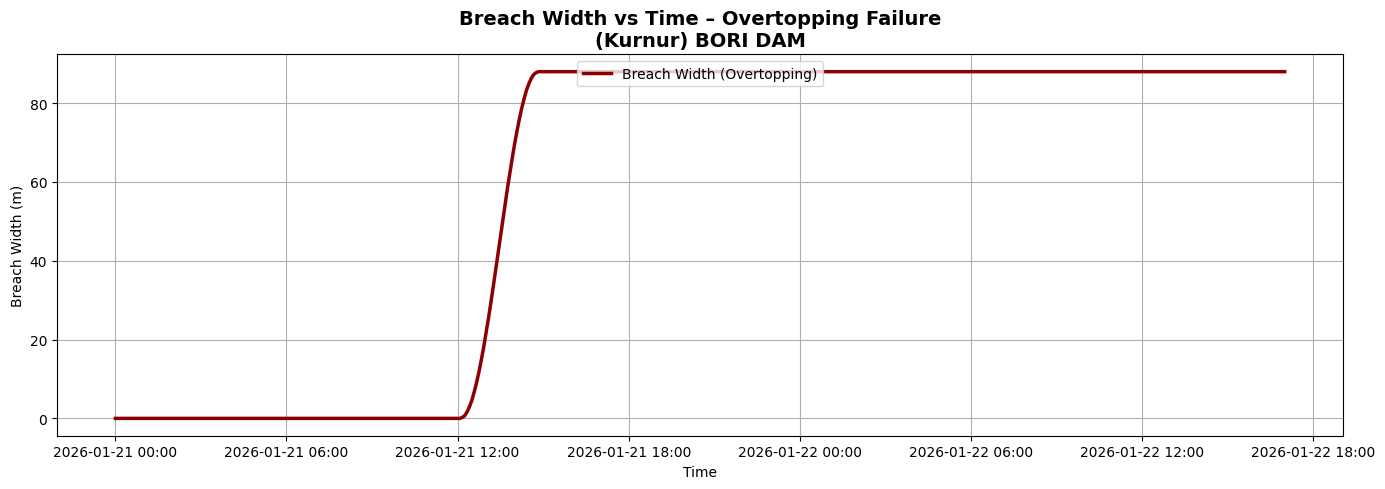

In [6]:
plt.figure(figsize=(14,5))
plt.plot(df_overtop["Time"], df_overtop["Breach Width"],
         color="darkred", linewidth=2.5,
         label="Breach Width (Overtopping)")

plt.title("Breach Width vs Time – Overtopping Failure\n(Kurnur) BORI DAM",
          fontsize=14, fontweight="bold")
plt.xlabel("Time")
plt.ylabel("Breach Width (m)")
plt.legend(loc="upper center", ncol=1, frameon=True)
plt.grid(True)

plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
plt.tight_layout()
plt.show()

In [7]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_overtop["Time"],
    y=df_overtop["Breach Width"],
    mode="lines",
    line=dict(width=3, color="firebrick"),
    name="Breach Width (Overtopping)"
))

fig.update_layout(
    title="Breach Width vs Time – Overtopping Failure<br>(Kurnur) BORI DAM",
    xaxis_title="Time",
    yaxis_title="Breach Width (m)",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5),
    template="plotly_white"
)

fig.show()

In [8]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_overtop["Time"],
    y=df_overtop["Breach Velocity"],
    mode="lines",
    line=dict(width=3, color="purple"),
    name="Breach Velocity (Overtopping)"
))

fig.update_layout(
    title="Breach Velocity vs Time – Overtopping Failure<br>(Kurnur) BORI DAM",
    xaxis_title="Time",
    yaxis_title="Velocity (m/s)",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5),
    template="plotly_white"
)

fig.show()

🟦 2. OVERTOPPING – BREACH VELOCITY

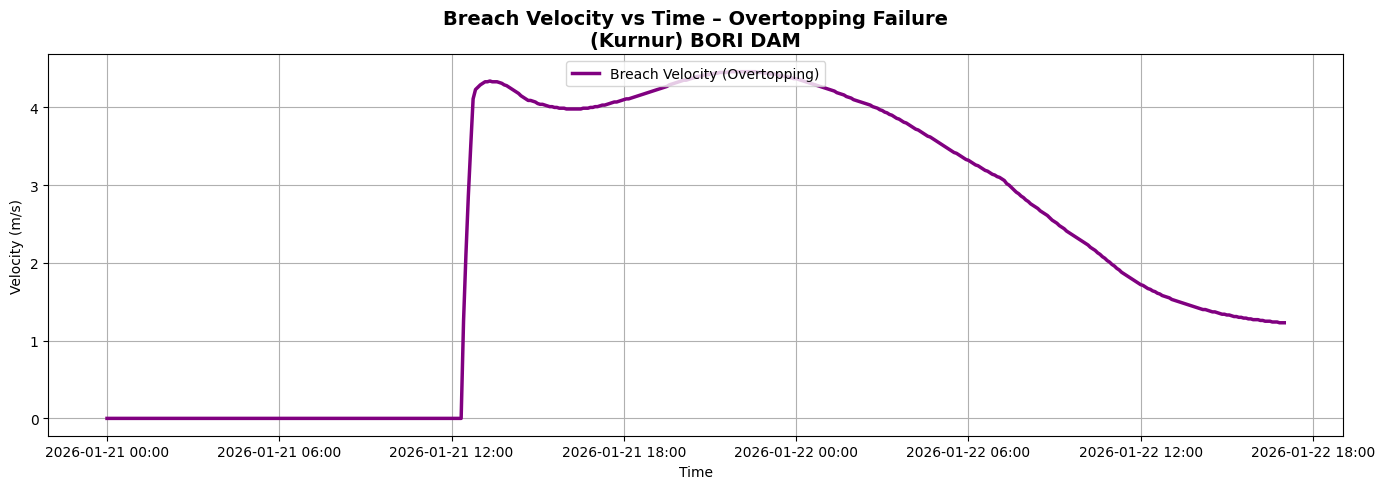

In [9]:
plt.figure(figsize=(14,5))
plt.plot(df_overtop["Time"], df_overtop["Breach Velocity"],
         color="purple", linewidth=2.5,
         label="Breach Velocity (Overtopping)")

plt.title("Breach Velocity vs Time – Overtopping Failure\n(Kurnur) BORI DAM",
          fontsize=14, fontweight="bold")
plt.xlabel("Time")
plt.ylabel("Velocity (m/s)")
plt.legend(loc="upper center", ncol=1, frameon=True)
plt.grid(True)

plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
plt.tight_layout()
plt.show()

🟦 3. PIPING – BREACH WIDTH

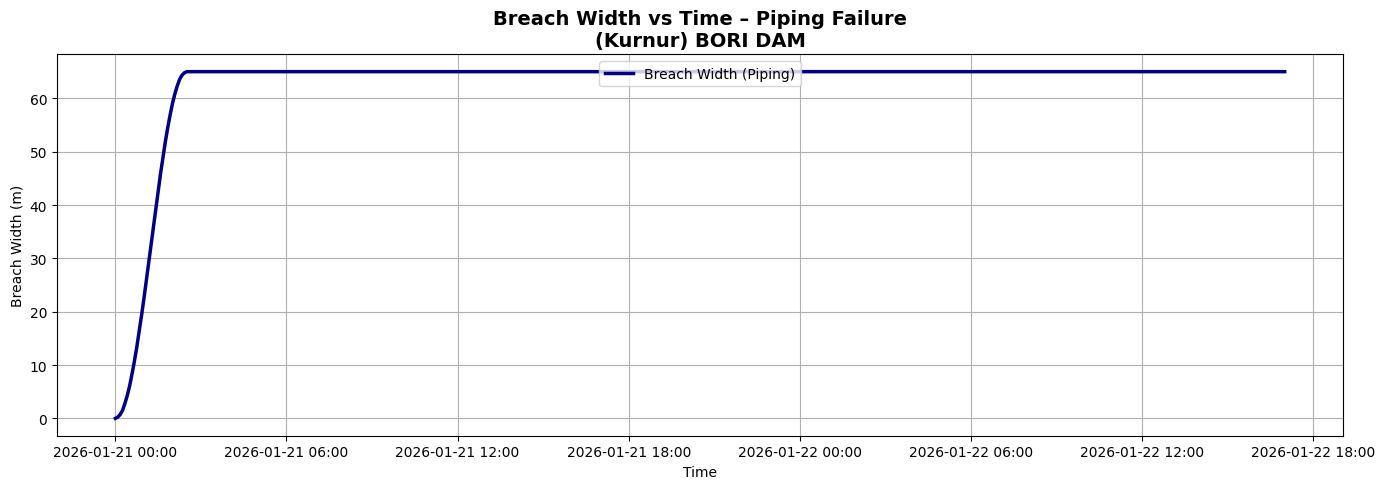

In [10]:
plt.figure(figsize=(14,5))
plt.plot(df_piping["Time"], df_piping["Breach Width"],
         color="navy", linewidth=2.5,
         label="Breach Width (Piping)")

plt.title("Breach Width vs Time – Piping Failure\n(Kurnur) BORI DAM",
          fontsize=14, fontweight="bold")
plt.xlabel("Time")
plt.ylabel("Breach Width (m)")
plt.legend(loc="upper center", ncol=1, frameon=True)
plt.grid(True)

plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
plt.tight_layout()
plt.show()

🟦 4. PIPING – BREACH VELOCITY

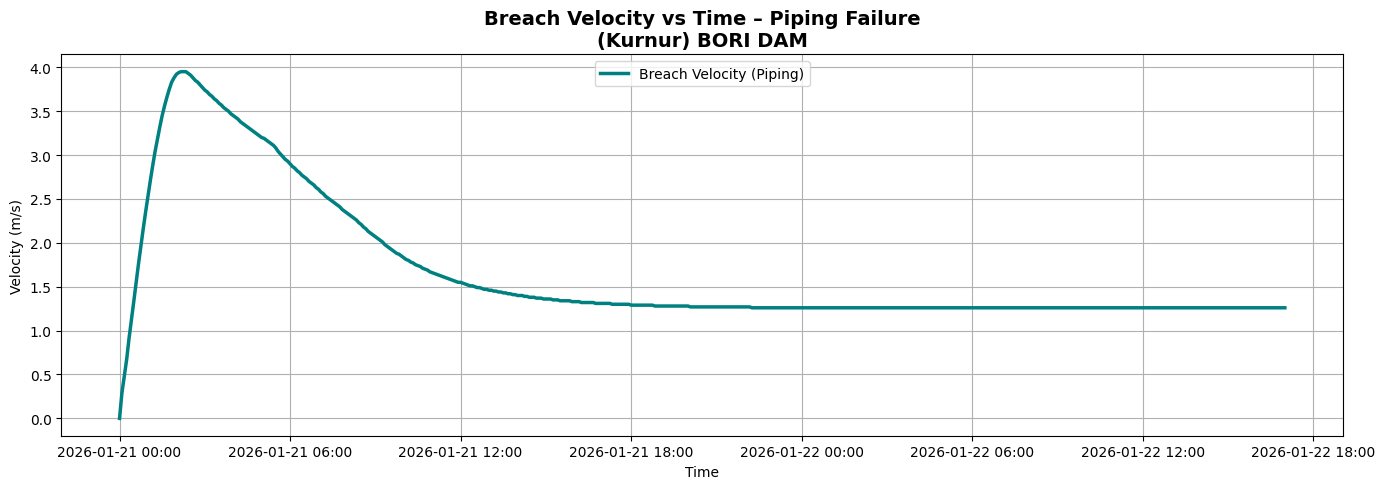

In [11]:
plt.figure(figsize=(14,5))
plt.plot(df_piping["Time"], df_piping["Breach Velocity"],
         color="teal", linewidth=2.5,
         label="Breach Velocity (Piping)")

plt.title("Breach Velocity vs Time – Piping Failure\n(Kurnur) BORI DAM",
          fontsize=14, fontweight="bold")
plt.xlabel("Time")
plt.ylabel("Velocity (m/s)")
plt.legend(loc="upper center", ncol=1, frameon=True)
plt.grid(True)

plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
plt.tight_layout()
plt.show()

==========================================

## **🟠 PLOTLY OUTPUTS (4 INTERACTIVE GRAPHS)**




5. OVERTOPPING – BREACH WIDTH (Plotly)

In [12]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_overtop["Time"],
    y=df_overtop["Breach Width"],
    mode="lines",
    line=dict(width=3, color="firebrick"),
    name="Breach Width (Overtopping)"
))

fig.update_layout(
    title="Breach Width vs Time – Overtopping Failure<br>(Kurnur) BORI DAM",
    xaxis_title="Time",
    yaxis_title="Breach Width (m)",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5),
    template="plotly_white"
)

fig.show()

🟧 6. OVERTOPPING – BREACH VELOCITY (Plotly)

In [13]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_overtop["Time"],
    y=df_overtop["Breach Velocity"],
    mode="lines",
    line=dict(width=3, color="purple"),
    name="Breach Velocity (Overtopping)"
))

fig.update_layout(
    title="Breach Velocity vs Time – Overtopping Failure<br>(Kurnur) BORI DAM",
    xaxis_title="Time",
    yaxis_title="Velocity (m/s)",
    legend=dict(orientation="h", y=1.02, x=0.5, xanchor="center"),
    template="plotly_white"
)

fig.show()

🟧 7. PIPING – BREACH WIDTH (Plotly)

In [14]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_piping["Time"],
    y=df_piping["Breach Width"],
    mode="lines",
    line=dict(width=3, color="navy"),
    name="Breach Width (Piping)"
))

fig.update_layout(
    title="Breach Width vs Time – Piping Failure<br>(Kurnur) BORI DAM",
    xaxis_title="Time",
    yaxis_title="Breach Width (m)",
    legend=dict(orientation="h", y=1.02, x=0.5, xanchor="center"),
    template="plotly_white"
)

fig.show()

🟧 8. PIPING – BREACH VELOCITY (Plotly)

In [15]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_piping["Time"],
    y=df_piping["Breach Velocity"],
    mode="lines",
    line=dict(width=3, color="teal"),
    name="Breach Velocity (Piping)"
))

fig.update_layout(
    title="Breach Velocity vs Time – Piping Failure<br>(Kurnur) BORI DAM",
    xaxis_title="Time",
    yaxis_title="Velocity (m/s)",
    legend=dict(orientation="h", y=1.02, x=0.5, xanchor="center"),
    template="plotly_white"
)

fig.show()